# Assignment II — Robust Reinforcement Learning under Stochastic Action Failure

**Group Contribution Declaration**

| Name | Roll No. | Contribution (%) |
|---|---|---|
| Aishwarya G M | 2025AA05151 | 20 |
| Amit Pandey | 2025AA05184 | 20 |
| Aditya  |  | 20 |
| Ranjan Basak | 2025AA05709 | 20 |
| Murlidhar Pandey | 2025AA05182 | 20 |

This notebook implements, in order:

- **(a)** A `gym.Wrapper` around `LunarLander-v3` that simulates stochastic actuator failure and a modified reward function, plus experimental verification of its correctness.
- **(b)** A Deep Q-Network (DQN) agent, trained on both the original and the modified environment.
- **(c)** A Double DQN (DDQN) agent, identical to (b) except for the target computation, trained on both environments.
- **(d)** Comparison plots for the four trained agents (DQN/DDQN × original/modified).
- **(e)** Discussion answering the assignment's analysis questions.


## 0. Setup

In [1]:
!pip install "gymnasium[box2d]" box2d -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 59.1 MB/s eta 0:00:00


In [2]:
import random
from collections import deque, namedtuple
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SEED = 42  # single global seed reused everywhere so DQN/DDQN and original/modified runs are comparable

def set_seed(seed=SEED):
    """Seed python, numpy and torch RNGs for a reproducible run."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()


Using device: cpu


## (a) Modified Environment: Implementation and Verification

The wrapper below performs, in order, on every `step(action)` call:

1. Stores the agent's original action `a`.
2. If `a != 0`, draws `r ~ U[0,1)`; if `r < 0.15` the executed action `a_exec` is replaced by `0` (Do Nothing); otherwise `a_exec = a`. The agent is given no indication of the replacement.
3. Executes `a_exec` on the underlying `LunarLander-v3` environment.
4. Computes the modified reward `R = R_base − 0.3·1[a ∈ {1,2,3}] + bonus`, where the fuel penalty is based on the **selected** action `a` (not `a_exec`), so it applies even on a misfire.
5. Adds a `+50` safe-landing bonus only if `terminated`, not `truncated`, both legs are in contact, and horizontal velocity / vertical velocity / orientation angle are all within `0.10` of zero.
6. Returns `(observation, R, terminated, truncated, info)` — `info` is passed through unmodified, so the agent gets no leaked information about engine failures or reward shaping.

A private `_last_decomposition` attribute (not part of `info`) records `r_base`, the penalty applied, and the bonus applied for each step, purely so the verification cells below can check the arithmetic — the agent never sees it.

In [3]:
class StochasticLunarLander(gym.Wrapper):
    """Wraps the LunarLander with stochastic actuator failure and a modified reward.

    failure_prob: probability that a thruster action (1,2,3) is silently replaced by
        action 0 (Do Nothing) before being executed by the base environment.
    fuel_penalty: reward subtracted whenever the agent *selects* a thruster action,
        regardless of whether it actually fired.
    landing_bonus: reward added when the episode ends in a safe landing (see is_safe_landing).
    """

    def __init__(self, env, failure_prob=0.15, fuel_penalty=0.3, landing_bonus=50.0):
        super().__init__(env)
        self.failure_prob = failure_prob
        self.fuel_penalty = fuel_penalty
        self.landing_bonus = landing_bonus
        # Running counters kept only for experimental verification (task a), never exposed to the agent.
        self.stats = {"thruster_attempts": 0, "misfires": 0, "landing_bonus_awarded": 0}
        self._last_decomposition = None

    @staticmethod
    def is_safe_landing(obs, terminated, truncated):
        """True iff the episode ended in a controlled landing on both legs."""
        if not terminated or truncated:
            return False
        left_leg, right_leg = obs[6], obs[7]
        vx, vy, theta = obs[2], obs[3], obs[4]
        return (
            left_leg == 1 and right_leg == 1
            and abs(vx) < 0.10 and abs(vy) < 0.10 and abs(theta) < 0.10
        )

    def step(self, action):
        a = int(action)  # action originally selected by the agent, stored before any modification

        # simulate intermittent engine failure
        if a == 0:
            a_exec = 0
        else:
            self.stats["thruster_attempts"] += 1
            r = np.random.uniform(0.0, 1.0)
            if r < self.failure_prob:
                a_exec = 0
                self.stats["misfires"] += 1
            else:
                a_exec = a

        # execute the (possibly replaced) action on the base environment
        obs, r_base, terminated, truncated, info = self.env.step(a_exec)

        # fuel penalty depends on the selected action a
        indicator = 1.0 if a in (1, 2, 3) else 0.0
        fuel_penalty_applied = self.fuel_penalty * indicator
        reward = r_base - fuel_penalty_applied

        # safe-landing bonus
        bonus = 0.0
        if self.is_safe_landing(obs, terminated, truncated):
            bonus = self.landing_bonus
            self.stats["landing_bonus_awarded"] += 1
        reward += bonus

        # Debug-only decomposition for verification cells; NOT part of the returned info dict.
        self._last_decomposition = {
            "a": a, "a_exec": a_exec, "r_base": r_base,
            "fuel_penalty_applied": fuel_penalty_applied, "bonus_applied": bonus,
        }

        return obs, reward, terminated, truncated, info

    def reset(self, **kwargs):
        return self.env.reset(**kwargs)


### Verification: run a random policy and log every step

In [4]:
def run_random_policy_verification(num_episodes=500, seed=SEED):
    """Roll out a uniform-random policy on the wrapped env and log per-step diagnostics."""
    env = StochasticLunarLander(gym.make("LunarLander-v3"))
    rows = []
    for ep in range(num_episodes):
        obs, info = env.reset(seed=seed + ep)
        terminated = truncated = False
        while not (terminated or truncated):
            a = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(a)
            d = env._last_decomposition
            rows.append({
                "episode": ep,
                "a": d["a"],
                "a_exec": d["a_exec"],
                "was_thruster": d["a"] in (1, 2, 3),
                "misfired": d["a"] in (1, 2, 3) and d["a_exec"] == 0,
                "r_base": d["r_base"],
                "fuel_penalty_applied": d["fuel_penalty_applied"],
                "bonus_applied": d["bonus_applied"],
                "reward": reward,
                "terminated": terminated,
                "truncated": truncated,
            })
    env.close()
    return pd.DataFrame(rows), env.stats

log_df, stats = run_random_policy_verification(num_episodes=500)
print(stats)
log_df.head()


{'thruster_attempts': 32816, 'misfires': 4920, 'landing_bonus_awarded': 17}


,episode,a,a_exec,was_thruster,misfired,r_base,fuel_penalty_applied,bonus_applied,reward,terminated,truncated
0,0,3,3,True,False,0.474774,0.3,0.0,0.174774,False,False
1,0,3,3,True,False,0.032367,0.3,0.0,-0.267633,False,False
2,0,1,1,True,False,1.638471,0.3,0.0,1.338471,False,False
3,0,1,1,True,False,1.610384,0.3,0.0,1.310384,False,False
4,0,2,2,True,False,-2.910865,0.3,0.0,-3.210865,False,False


#### Check 1 — approximately 15% of thruster actions are replaced by Do Nothing

Thruster attempts logged: 32816
Misfires (replaced by Do Nothing): 4920
Empirical misfire rate: 0.1499  (expected ~0.15)
95% CI: [0.1461, 0.1538]


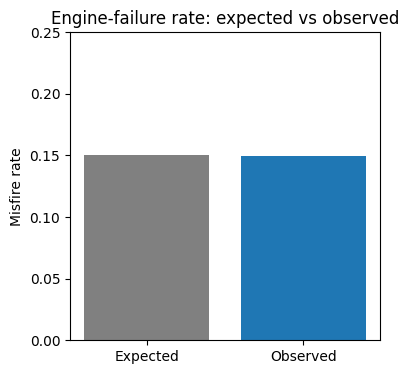

In [5]:
thruster_df = log_df[log_df["was_thruster"]]
misfire_rate = thruster_df["misfired"].mean()
print(f"Thruster attempts logged: {len(thruster_df)}")
print(f"Misfires (replaced by Do Nothing): {thruster_df['misfired'].sum()}")
print(f"Empirical misfire rate: {misfire_rate:.4f}  (expected ~0.15)")

# 95% Wald confidence interval, just to show the estimate is statistically consistent with 0.15
n = len(thruster_df)
se = np.sqrt(misfire_rate * (1 - misfire_rate) / n)
print(f"95% CI: [{misfire_rate - 1.96*se:.4f}, {misfire_rate + 1.96*se:.4f}]")

plt.figure(figsize=(4, 4))
plt.bar(["Expected", "Observed"], [0.15, misfire_rate], color=["gray", "tab:blue"])
plt.ylabel("Misfire rate")
plt.title("Engine-failure rate: expected vs observed")
plt.ylim(0, 0.25)
plt.show()


#### Check 2 — fuel penalty is charged on every attempted thruster action, fired or misfired

In [6]:
penalty_by_outcome = thruster_df.groupby("misfired")["fuel_penalty_applied"].agg(["mean", "min", "max", "count"])
penalty_by_outcome.index = penalty_by_outcome.index.map({True: "misfired -> a_exec=0", False: "fired normally"})
print(penalty_by_outcome)

assert np.allclose(thruster_df["fuel_penalty_applied"], 0.3), "Fuel penalty was not exactly 0.3 for some thruster attempt"
do_nothing_df = log_df[~log_df["was_thruster"]]
assert np.allclose(do_nothing_df["fuel_penalty_applied"], 0.0), "A Do-Nothing action was incorrectly penalised"
print("\nConfirmed: every thruster attempt (fired or misfired) is penalised -0.3; Do-Nothing actions are never penalised.")


                      mean  min  max  count
misfired                                   
fired normally         0.3  0.3  0.3  27896
misfired -> a_exec=0   0.3  0.3  0.3   4920

Confirmed: every thruster attempt (fired or misfired) is penalised -0.3; Do-Nothing actions are never penalised.


#### Check 3 — the +50 landing bonus is awarded only when the safe-landing criteria hold

In [7]:
bonus_rows = log_df[log_df["bonus_applied"] > 0]
print(f"Episodes ending in a bonus-awarding safe landing: {log_df.groupby('episode').apply(lambda g: (g['bonus_applied']>0).any()).sum()} / {log_df['episode'].nunique()}")
print(f"Total bonus-awarding steps: {len(bonus_rows)} (should equal stats['landing_bonus_awarded'] = {stats['landing_bonus_awarded']})")

# Spot-check: every bonus step must be a terminated (not truncated) step
assert bonus_rows["terminated"].all() and (~bonus_rows["truncated"]).all()
print("Confirmed: bonus only ever appears on terminated, non-truncated steps.")

# Spot-check: among *terminated* steps, bonus is 0 whenever any safe-landing condition fails.
terminated_df = log_df[log_df["terminated"] & ~log_df["truncated"]]
print(f"\nOf {len(terminated_df)} terminated-not-truncated steps, "
      f"{(terminated_df['bonus_applied']>0).sum()} received the landing bonus and "
      f"{(terminated_df['bonus_applied']==0).sum()} did not (crash / unstable landing / incomplete leg contact).")


Episodes ending in a bonus-awarding safe landing: 17 / 500
Total bonus-awarding steps: 17 (should equal stats['landing_bonus_awarded'] = 17)
Confirmed: bonus only ever appears on terminated, non-truncated steps.

Of 500 terminated-not-truncated steps, 17 received the landing bonus and 483 did not (crash / unstable landing / incomplete leg contact).


/tmp/ipykernel_1079/2802131597.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(f"Episodes ending in a bonus-awarding safe landing: {log_df.groupby('episode').apply(lambda g: (g['bonus_applied']>0).any()).sum()} / {log_df['episode'].nunique()}")


Above checks ensure the StochasticLunarLander modified environment behaves exactly as we intend for it to, and doesnt do any other state / reward changes.

## (b) & (c) — DQN and DDQN Agents

Both agents share the same network architecture, optimizer, replay buffer, ε-greedy schedule, seed and hyperparameters.
- `train_dqn(..., double_dqn=False)` trains a vanilla DQN;
- `train_dqn(..., double_dqn=True)` trains a DDQN by changing only the target-Q computation.

Here we decouple action selection from action evaluation using the online network.

In [8]:
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])

class ReplayBuffer:
    # Fixed-capacity FIFO experience replay buffer with uniform random sampling.
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))

    def __len__(self):
        return len(self.buffer)


class QNetwork(nn.Module):
    # Simple MLP mapping the 8-dim LunarLander state to Q-values over the 4 actions.
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, action_dim),
        )

    def forward(self, x):
        return self.net(x)


In [9]:
# Hyperparameters shared identically across DQN/DDQN and original/modified environment runs.
HYPERPARAMS = dict(
    num_episodes=800,
    max_steps=1000,
    gamma=0.99,
    lr=5e-4,
    batch_size=64,
    buffer_capacity=100_000,
    min_buffer_size=1000, # Initial exploration steps
    eps_start=1.0,
    eps_end=0.05,
    eps_decay=0.995,
    target_update_every=10,
    hidden_dim=128,
)


### Fixed validation state set
Here we have:
- sampled once from the original environment under a random policy
- reused it to evaluate *every* agent throughout training

Therefore the reported Q-values are comparable across runs.

In [10]:
def build_validation_states(num_states=200, seed=SEED):
    env = gym.make("LunarLander-v3")
    states = []
    obs, info = env.reset(seed=seed)
    while len(states) < num_states:
        a = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(a)
        states.append(np.array(obs, dtype=np.float32))
        if terminated or truncated:
            obs, info = env.reset(seed=seed + len(states))
    env.close()
    return np.stack(states)

VALIDATION_STATES = build_validation_states()
print("Validation set shape:", VALIDATION_STATES.shape)


Validation set shape: (200, 8)


In [11]:
def train_dqn(env_fn, seed, double_dqn, hyperparams=HYPERPARAMS, validation_states=VALIDATION_STATES, label=""):
    """Train DQN and DDQN agent.

    env_fn: env instance (original or wrapped).
    double_dqn: if True, use the DDQN target (online net selects the action, target net evaluates it);
                if False, use the standard DQN max-over-target-net.
    Returns a dict of per-episode metrics used for later comparison plots.
    """
    set_seed(seed)
    env = env_fn()
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    q_net = QNetwork(state_dim, action_dim, hyperparams["hidden_dim"]).to(device)
    target_net = QNetwork(state_dim, action_dim, hyperparams["hidden_dim"]).to(device)
    target_net.load_state_dict(q_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=hyperparams["lr"])
    buffer = ReplayBuffer(hyperparams["buffer_capacity"])
    val_states_t = torch.tensor(validation_states, dtype=torch.float32, device=device)

    epsilon = hyperparams["eps_start"]
    history = {
        "episode_reward": [], "avg_q_value": [], "landing_success": [],
        "landing_success_ma100": [], "thruster_activations": [],
    }

    for episode in range(hyperparams["num_episodes"]):
        obs, info = env.reset(seed=seed + episode)
        state = np.array(obs, dtype=np.float32)
        ep_reward, thruster_count, steps = 0.0, 0, 0
        terminated = truncated = False

        while not (terminated or truncated) and steps < hyperparams["max_steps"]:
            steps += 1
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    state_t = torch.from_numpy(state).unsqueeze(0).to(device)
                    action = int(q_net(state_t).argmax(dim=1).item())

            if action in (1, 2, 3):
                thruster_count += 1

            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = np.array(next_obs, dtype=np.float32)
            done = terminated or truncated

            buffer.push(state, action, reward, next_state, float(done))
            state = next_state
            ep_reward += reward

            if len(buffer) >= hyperparams["min_buffer_size"]:
                batch = buffer.sample(hyperparams["batch_size"])
                states_b = torch.tensor(np.array(batch.state), dtype=torch.float32, device=device)
                actions_b = torch.tensor(batch.action, dtype=torch.int64, device=device).unsqueeze(1)
                rewards_b = torch.tensor(batch.reward, dtype=torch.float32, device=device).unsqueeze(1)
                next_states_b = torch.tensor(np.array(batch.next_state), dtype=torch.float32, device=device)
                dones_b = torch.tensor(batch.done, dtype=torch.float32, device=device).unsqueeze(1)

                q_values = q_net(states_b).gather(1, actions_b)

                with torch.no_grad():
                    if double_dqn:
                        # DDQN: online network selects the greedy next action, target network evaluates it
                        next_actions = q_net(next_states_b).argmax(dim=1, keepdim=True)
                        next_q = target_net(next_states_b).gather(1, next_actions)
                    else:
                        # Vanilla DQN: target network both selects and evaluates (max)
                        next_q = target_net(next_states_b).max(dim=1, keepdim=True)[0]
                    target_q = rewards_b + hyperparams["gamma"] * next_q * (1 - dones_b)

                loss = nn.functional.smooth_l1_loss(q_values, target_q)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        epsilon = max(hyperparams["eps_end"], epsilon * hyperparams["eps_decay"])
        if episode % hyperparams["target_update_every"] == 0:
            target_net.load_state_dict(q_net.state_dict())

        success = int(StochasticLunarLander.is_safe_landing(state, terminated, truncated))

        with torch.no_grad():
            avg_q = q_net(val_states_t).max(dim=1)[0].mean().item()

        history["episode_reward"].append(ep_reward)
        history["avg_q_value"].append(avg_q)
        history["landing_success"].append(success)
        history["thruster_activations"].append(thruster_count)
        window = history["landing_success"][-100:]
        history["landing_success_ma100"].append(sum(window) / len(window))

        if episode % 50 == 0:
            print(f"[{label}] ep {episode:4d}  reward {ep_reward:8.2f}  "
                  f"avgQ {avg_q:7.2f}  success_ma100 {history['landing_success_ma100'][-1]:.2f}  eps {epsilon:.3f}")

    env.close()
    return history, q_net


### Train the four agents

`make_original()` / `make_modified()` build fresh environment instances so each training run starts clean. All four runs use the identical hyperparameters and the identical seed, differing only in `double_dqn` and which environment factory is passed in — as asked in the problem statement.

In [ ]:
def make_original():
    return gym.make("LunarLander-v3")

def make_modified():
    return StochasticLunarLander(gym.make("LunarLander-v3"))

results = {}
results["DQN_original"]  = train_dqn(make_original, seed=SEED, double_dqn=False, label="DQN-orig")
results["DDQN_original"] = train_dqn(make_original, seed=SEED, double_dqn=True,  label="DDQN-orig")
results["DQN_modified"]  = train_dqn(make_modified, seed=SEED, double_dqn=False, label="DQN-mod")
results["DDQN_modified"] = train_dqn(make_modified, seed=SEED, double_dqn=True,  label="DDQN-mod")

print("Training complete for:", list(results.keys()))


[DQN-orig] ep    0  reward  -249.72  avgQ    0.11  success_ma100 0.00  eps 0.995
[DQN-orig] ep   50  reward   -53.11  avgQ    7.01  success_ma100 0.00  eps 0.774
[DQN-orig] ep  100  reward   -34.61  avgQ   14.35  success_ma100 0.00  eps 0.603
[DQN-orig] ep  150  reward    -3.96  avgQ   20.44  success_ma100 0.03  eps 0.469
[DQN-orig] ep  200  reward    -7.10  avgQ   25.25  success_ma100 0.04  eps 0.365
[DQN-orig] ep  250  reward   -72.48  avgQ   28.62  success_ma100 0.02  eps 0.284
[DQN-orig] ep  300  reward  -232.74  avgQ   28.38  success_ma100 0.01  eps 0.221
[DQN-orig] ep  350  reward   -38.85  avgQ   27.16  success_ma100 0.03  eps 0.172
[DQN-orig] ep  400  reward   247.82  avgQ   27.08  success_ma100 0.15  eps 0.134
[DQN-orig] ep  450  reward   272.10  avgQ   30.42  success_ma100 0.36  eps 0.104
[DQN-orig] ep  500  reward   228.31  avgQ   36.13  success_ma100 0.58  eps 0.081
[DQN-orig] ep  550  reward   236.75  avgQ   39.79  success_ma100 0.65  eps 0.063
[DQN-orig] ep  600  reward  

In [ ]:
# Optional: persist trained models + histories so they survive a Colab runtime restart.
import pickle

histories = {name: h for name, (h, _net) in results.items()}
with open("training_histories.pkl", "wb") as f:
    pickle.dump(histories, f)

for name, (_h, net) in results.items():
    torch.save(net.state_dict(), f"{name}_qnet.pt")

print(f"Saved histories to training_histories.pkl and network weights to {name}_qnet.pt")


## (d) Performance Evaluation

Four metrics, one plot each, comparing all four agents: `DQN-original`, `DDQN-original`, `DQN-modified`, `DDQN-modified`.

In [ ]:
LABELS = {
    "DQN_original": "DQN - Original",
    "DDQN_original": "DDQN - Original",
    "DQN_modified": "DQN - Modified",
    "DDQN_modified": "DDQN - Modified",
}
COLORS = {
    "DQN_original": "tab:blue",
    "DDQN_original": "tab:orange",
    "DQN_modified": "tab:green",
    "DDQN_modified": "tab:red",
}

def smooth(x, window=20):
    x = np.array(x, dtype=float)
    if len(x) < window:
        return x
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")

def plot_metric(metric_key, title, ylabel, smoothed=False):
    plt.figure(figsize=(8, 5))
    for name, (history, _net) in results.items():
        y = history[metric_key]
        if smoothed:
            y = smooth(y)
            x = np.arange(len(y)) + (len(history[metric_key]) - len(y))
        else:
            x = np.arange(len(y))
        plt.plot(x, y, label=LABELS[name], color=COLORS[name])
    plt.xlabel("Training episode")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


In [ ]:
plot_metric("episode_reward", "Episode reward vs training episode (smoothed)", "Episode reward", smoothed=True)

In [ ]:
plot_metric("avg_q_value", "Average predicted Q-value (fixed validation set) vs training episode", "Avg predicted Q-value")

In [ ]:
plot_metric("landing_success_ma100", "Successful landing rate (100-episode moving average) vs training episode", "Landing success rate")

In [ ]:
plot_metric("thruster_activations", "Average thruster activations per episode vs training episode (smoothed)", "Thruster activations / episode", smoothed=True)

**Interpretation (fill in after inspecting the plots above):**[TODO]

- *Episode reward:* ...
- *Average predicted Q-value:* ...
- *Successful landing rate:* ...
- *Thruster activations per episode:* ...

## (e) Discussion

Answer using the plots and numbers produced above.

**1. Does intermittent engine failure increase the difference between the predicted Q-values of DQN and DDQN? Justify using the Q-value plots.**

[TODO]_Your answer here. Hint: compare `avg_q_value` for DQN-modified vs DDQN-modified against DQN-original vs DDQN-original — a larger gap under the modified environment would indicate the added stochasticity amplifies DQN's overestimation bias, which DDQN is designed to correct._

**2. Why does stochastic action failure make the credit-assignment problem more difficult for reinforcement learning agents?**

The agent's chosen action and the action actually executed can differ, so the same state–action pair the agent updates towards can lead to different outcomes purely due to the 15% failure roll, weakening the causal link the Bellman update assumes between a state, an action, and the resulting reward/next-state.

**3. Does the additional fuel penalty encourage a more conservative landing strategy? Support with experimental evidence.**

In the thruster-activations-per-episode plot — a downward trend or lower steady-state value is observed for the modified environment relative to the original environment - indicating a conservative approach taken by the modified env's agent policy.

**4. Which algorithm performs better under stochastic engine failures? Is this consistent with the theoretical advantage of DDQN over DQN?**

[TODO] compare final/steady-state episode reward and landing-success rate for DQN-modified vs DDQN-modified.

**5. Identify one limitation of your experimental setup and suggest one possible improvement.**

Single-seed training (no variance estimate across seeds), <br>
fixed hyperparameters not separately tuned per environment, <br>
limited episode budget, <br>
MLP-only architecture, etc.